In [19]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("zalando-research/fashionmnist")

# print("Path to dataset files:", path)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import optuna
from torch.utils.data import Dataset, DataLoader

import joblib

In [21]:
data_train = pd.read_csv(r"C:\Learning_ML\DL_projects\Fashion_MNIST\fashionmnist\versions\4\fashion-mnist_train.csv")
data_test = pd.read_csv(r"C:\Learning_ML\DL_projects\Fashion_MNIST\fashionmnist\versions\4\fashion-mnist_test.csv")
data_train.head(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


In [22]:
print(data_train.shape)
print(data_test.shape)

(60000, 785)
(10000, 785)


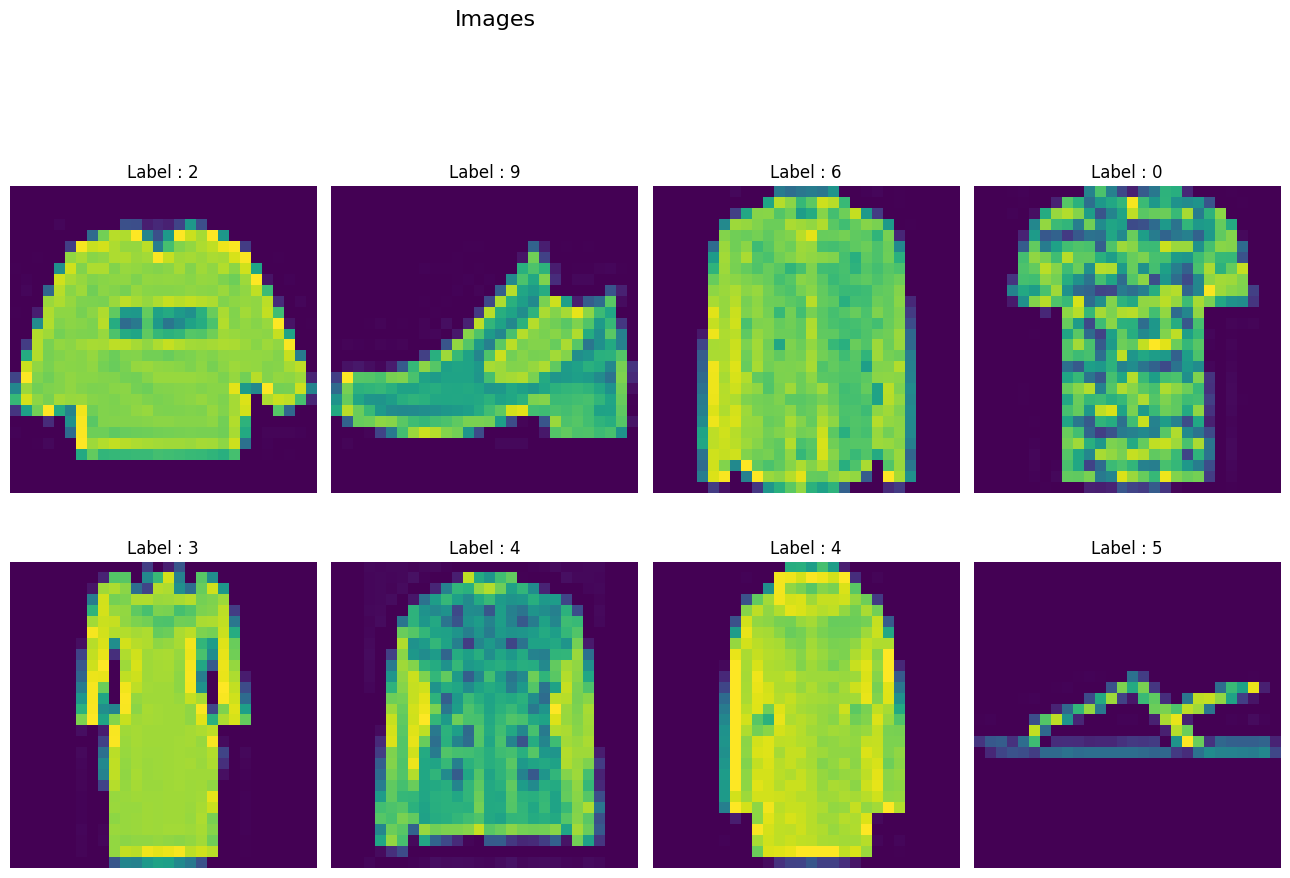

In [23]:
fig, axis = plt.subplots(2,4,figsize=(10,10))
fig.suptitle("Images",fontsize=16)
for i, ax in enumerate(axis.flat):
    img = data_train.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label : {data_train.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1.3,0.96])
plt.show()

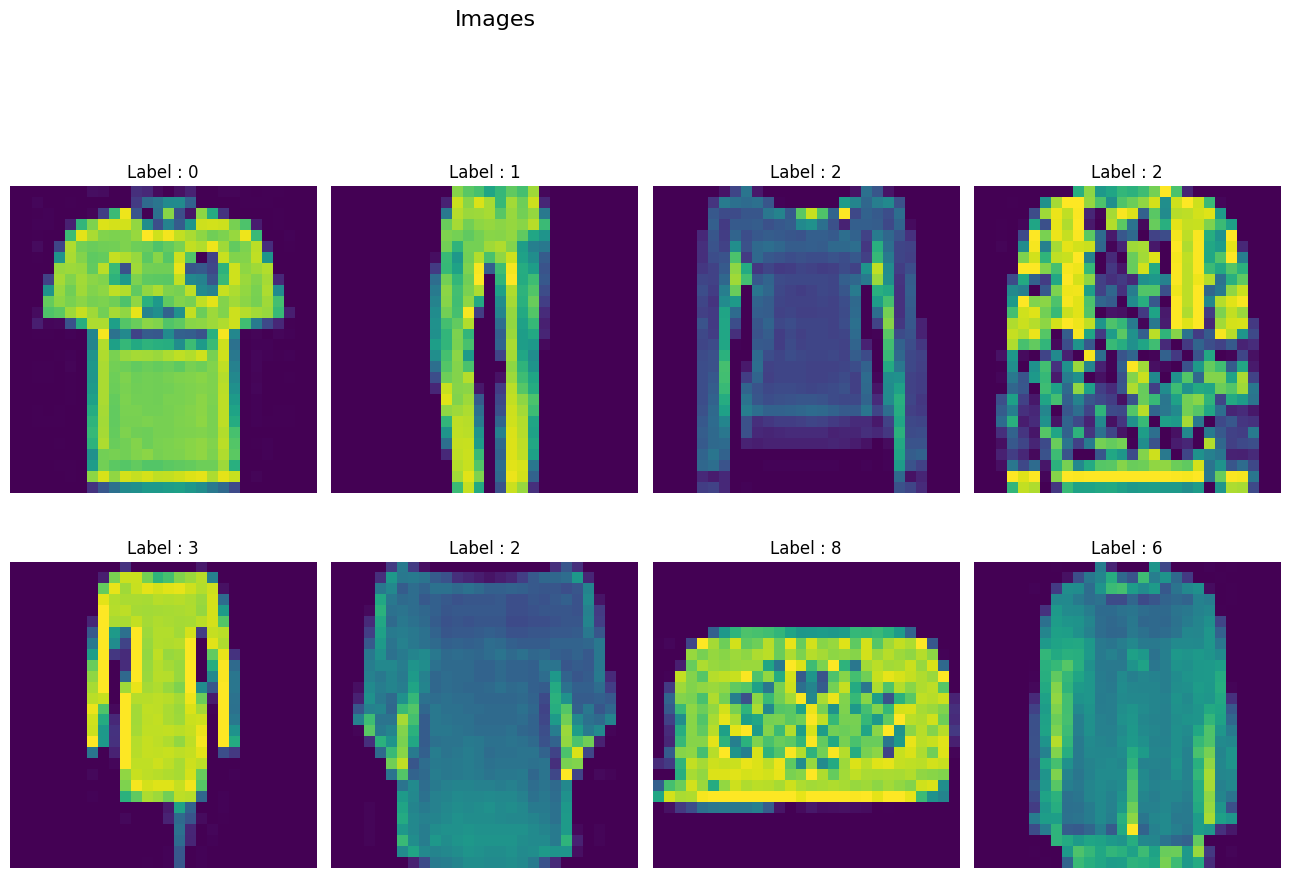

In [24]:
fig, axis = plt.subplots(2,4,figsize=(10,10))
fig.suptitle("Images",fontsize=16)
for i, ax in enumerate(axis.flat):
    img = data_test.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label : {data_test.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1.3,0.96])
plt.show()

In [25]:
xtrain = data_train.iloc[:, 1:]
ytrain = data_train.iloc[:, 0]

xtest = data_test.iloc[:, 1:]
ytest = data_test.iloc[:, 0]

In [26]:
# Scaling
xtrain = xtrain/255.0
xtest = xtest/255.0

In [27]:
xtrain

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.019608,0.0,0.0,...,0.000000,0.000000,0.000000,0.117647,0.168627,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.003922,0.007843,0.0,0.0,0.000000,0.0,0.0,...,0.011765,0.000000,0.000000,0.000000,0.000000,0.003922,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
59996,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.286275,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
59997,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.627451,0.635294,0.639216,0.529412,0.368627,0.000000,0.0,0.0,0.0,0.0
59998,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


In [28]:
class CustomData(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.features)
    def __getitem__(self, key):
        return self.features[key], self.labels[key]

In [29]:
train_data = CustomData(xtrain.to_numpy(), ytrain.to_numpy())
test_data = CustomData(xtest.to_numpy(), ytest.to_numpy())

In [30]:
train_data[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0157, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.2431, 0.2392, 0.0824, 0.1137, 0.0902,
         0.2000, 0.5333, 0.2392, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [31]:
class TheNN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_layers, neuron_per_layer, dropout):
        super().__init__()
        layers = []
        for i in range(hidden_layers):
            layers.append(nn.Linear(input_dim, neuron_per_layer))
            layers.append(nn.BatchNorm1d(neuron_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = neuron_per_layer
        layers.append(nn.Linear(neuron_per_layer, output_dim))
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

In [32]:
def objective(trail):
    hidden_layer = trail.suggest_int("Hidden layer", 1,5)
    neuron_per_layer = trail.suggest_int("Neuron per layer",16,128,step=8)
    epoch = trail.suggest_int("Epoch", 20, 50, step=10)
    lr = trail.suggest_float("Learning rate", 1e-4, 1e-1, log=True)
    dropout = trail.suggest_float("Dropout", 0.1, 0.5, step=0.1)
    batch_size = trail.suggest_categorical("Batch size", [16, 32, 64, 128])
    optimizer_name = trail.suggest_categorical("Optimizer", ["SGD", "Adam", "RMSprop"])
    weight_decay = trail.suggest_float("Weight decay", 1e-5, 1e-3, log=True)

    train_load = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_load = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    input_dim = 784
    output_dim = 10

    model = TheNN(input_dim, output_dim, hidden_layer, neuron_per_layer, dropout)

    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    for ep in range(epoch):
        ep_loss = 0
        for batch_feature, batch_labels in train_load:
            output = model(batch_feature)
            loss = criterion(output, batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_loss = ep_loss + loss.item()

    model.eval()

    total = 0
    correct = 0
    with torch.no_grad():
        for batch_feature, batch_labels in test_load:
            output = model(batch_feature)
            _, predicted = torch.max(output.data, 1)
            total += batch_labels.shape[0]
            correct += (predicted == batch_labels).sum().item()
    test_accuracy = correct/total
    return test_accuracy

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-08-13 23:43:50,980] A new study created in memory with name: no-name-d028b39d-8055-486d-a53e-20fdcfe91487


In [ ]:
study.best_trial

In [ ]:
study.best_value

In [ ]:
study.best_params